In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('NSE All Share Historical Data (2).csv')
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,22/12/2023,"74,023.27","74,288.88","74,430.47","73,993.49",423.20M,-0.36%
1,21/12/2023,"74,289.02","73,397.71","74,292.76","73,397.71",760.93M,1.21%
2,20/12/2023,"73,397.71","72,470.10","73,399.61","72,470.10",552.22M,1.28%
3,19/12/2023,"72,470.10","72,404.91","72,489.21","72,320.32",411.06M,0.09%
4,18/12/2023,"72,404.91","72,389.23","72,413.13","72,276.75",324.15M,0.02%


In [2]:
print(df.columns.tolist())

['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


In [3]:
df.shape

(2948, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2948 entries, 0 to 2947
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2948 non-null   object
 1   Price     2948 non-null   object
 2   Open      2948 non-null   object
 3   High      2948 non-null   object
 4   Low       2948 non-null   object
 5   Vol.      1651 non-null   object
 6   Change %  2948 non-null   object
dtypes: object(7)
memory usage: 161.3+ KB


In [5]:
##  Checking for missing values

df.isnull().sum()

Date           0
Price          0
Open           0
High           0
Low            0
Vol.        1297
Change %       0
dtype: int64

In [6]:
##  Checking basic statistics

df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,2948,2948,2948,2948,2948,1651,2948
unique,2948,2939,2938,2932,2938,1614,501
top,22/12/2023,"26,609.34","20,658.28","37,259.65","37,278.34",1.06B,0.02%
freq,1,2,3,4,3,3,35


In [7]:
## Cleaning the data

In [8]:
## Converting the  Date to proper format

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df['Date'].head())

0   2023-12-22
1   2023-12-21
2   2023-12-20
3   2023-12-19
4   2023-12-18
Name: Date, dtype: datetime64[ns]


In [9]:
##  Clean Change % column

df['Change %'] = df['Change %'].str.replace('%', '').astype(float)
print(df['Change %'].head())

0   -0.36
1    1.21
2    1.28
3    0.09
4    0.02
Name: Change %, dtype: float64


In [10]:
##  Drop the missing Volume rows

df = df.dropna(subset=['Vol.'])
print(df.shape)

(1651, 7)


In [11]:
##  Confirm everything is clean

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 2042
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1651 non-null   datetime64[ns]
 1   Price     1651 non-null   object        
 2   Open      1651 non-null   object        
 3   High      1651 non-null   object        
 4   Low       1651 non-null   object        
 5   Vol.      1651 non-null   object        
 6   Change %  1651 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 103.2+ KB
None


In [12]:
def convert_volume(val):
    if pd.isna(val):
        return 0
    val = str(val).replace(',', '')
    if 'B' in val:
        return float(val.replace('B', '')) * 1000000000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1000000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1000
    else:
        return float(val)

df['Vol.'] = df['Vol.'].apply(convert_volume)
print(df['Vol.'].head())

0    423200000.0
1    760930000.0
2    552220000.0
3    411060000.0
4    324150000.0
Name: Vol., dtype: float64


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1651 entries, 0 to 2042
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1651 non-null   datetime64[ns]
 1   Price     1651 non-null   object        
 2   Open      1651 non-null   object        
 3   High      1651 non-null   object        
 4   Low       1651 non-null   object        
 5   Vol.      1651 non-null   float64       
 6   Change %  1651 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 103.2+ KB
None


In [14]:
## Now let us analyze the data

In [15]:
print(df.describe())

                                Date          Vol.     Change %
count                           1651  1.651000e+03  1651.000000
mean   2020-06-09 23:04:10.757117184  3.419977e+08     0.067929
min              2015-09-23 00:00:00  5.188000e+07    -4.910000
25%              2018-05-02 12:00:00  1.925800e+08    -0.290000
50%              2020-08-26 00:00:00  2.669500e+08     0.020000
75%              2022-04-25 12:00:00  3.994200e+08     0.380000
max              2023-12-22 00:00:00  5.440000e+09     6.230000
std                              NaN  2.805905e+08     0.885646


In [16]:
##  Highest price ever recorded

highest_price = df.loc[df['Price'].idxmax()]
print(highest_price)

Date        2023-12-21 00:00:00
Price                 74,289.02
Open                  73,397.71
High                  74,292.76
Low                   73,397.71
Vol.                760930000.0
Change %                   1.21
Name: 1, dtype: object


In [17]:
##  Lowest price ever recorded

lowest_price = df.loc[df['Price'].idxmin()]
print(lowest_price)

Date        2020-04-06 00:00:00
Price                 20,669.38
Open                  21,094.62
High                  21,208.95
Low                   20,651.59
Vol.                336420000.0
Change %                  -2.02
Name: 920, dtype: object


In [18]:
##   Average closing price

print(f"Average Closing Price: {df['Price'].mean():,.2f}")

TypeError: Could not convert string '74,023.2774,289.0273,397.7172,470.1072,404.9172,389.2372,455.8372,299.7971,907.2671,669.9171,541.7471,457.9271,808.6471,250.1770,946.8371,419.8771,365.2571,283.3471,041.0571,353.8171,230.4971,052.8571,003.9871,066.5571,008.7871,112.9971,025.1671,014.3470,876.3570,612.8170,854.1870,819.5870,773.3870,613.6070,479.6270,196.9370,042.2870,581.7669,236.1968,111.7167,136.5867,084.9567,206.1667,217.7766,876.9266,915.4167,098.8067,353.2367,326.1267,037.9367,200.6967,133.1967,100.4966,984.6267,101.5766,454.5766,570.1966,482.2866,770.9766,382.1466,448.6366,652.1766,882.6467,324.5968,271.1468,335.7268,359.2267,877.1767,395.7467,347.7367,414.4066,760.2067,296.1868,143.3468,082.1168,286.2868,334.6868,279.1467,527.1966,548.9966,439.5366,490.3466,151.3865,558.9165,401.8265,492.9265,488.6765,202.4164,743.9664,663.7864,625.2864,928.9865,210.4965,325.3765,205.3564,167.3965,309.6565,336.8065,198.0865,263.0664,267.3664,192.2064,337.5265,056.3965,482.9165,687.1665,991.02

In [ ]:
##  Best performing day

best_day = df.loc[df['Change %'].idxmax()]
print(best_day)

In [ ]:
##  Worst performing day

worst_day = df.loc[df['Change %'].idxmin()]
print(worst_day)

In [ ]:
##  Average daily trading volume

print(f"Average Daily Volume: {df['Vol.'].mean():,.0f}")

In [ ]:
## Visualization

In [ ]:
##   Price trend over time (Line Chart)

df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Price'].mean()
plt.figure(figsize=(10,5))
yearly_avg.plot(kind='bar', color='steelblue')
plt.title('Yearly Average NSE All Share Index Price')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

In [ ]:
##   Daily Change % Distribution (Histogram)

plt.figure(figsize=(10,5))
plt.hist(df['Change %'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Daily Price Changes')
plt.xlabel('Change %')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
##   Trading Volume over time (Bar Chart)

plt.figure(figsize=(14,6))
plt.bar(df['Date'], df['Vol.'], color='orange')
plt.title('NSE Daily Trading Volume (2015-2023)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

In [ ]:
## Yearly average price (Bar Chart)

df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Price'].mean()
plt.figure(figsize=(10,5))
yearly_avg.plot(kind='bar', color='steelblue')
plt.title('Yearly Average NSE All Share Index Price')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

In [ ]:
## High vs Low price over time

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['High'], color='green', label='High')
plt.plot(df['Date'], df['Low'], color='red', label='Low')
plt.title('NSE Daily High vs Low Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('nse_cleaned.csv', index=False)
print('File saved successfully')

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('NSE All Share Historical Data (2).csv')

# Clean the data
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = df[col].str.replace(',', '').astype(float)
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

def convert_volume(val):
    if pd.isna(val):
        return 0
    val = str(val).replace(',', '')
    if 'B' in val:
        return float(val.replace('B', '')) * 1000000000
    elif 'M' in val:
        return float(val.replace('M', '')) * 1000000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1000
    else:
        return float(val)

df['Vol.'] = df['Vol.'].apply(convert_volume)
df = df.sort_values('Date')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print('Data loaded successfully')
print(df.shape)

Data loaded successfully
(2948, 9)


In [20]:
##   Moving Average Analysis

df['MA7'] = df['Price'].rolling(window=7).mean()
df['MA30'] = df['Price'].rolling(window=30).mean()
print("=== MOVING AVERAGE ANALYSIS ===")
print(f"Current 7-Day Moving Average: {df['MA7'].iloc[-1]:,.2f}")
print(f"Current 30-Day Moving Average: {df['MA30'].iloc[-1]:,.2f}")

=== MOVING AVERAGE ANALYSIS ===
Current 7-Day Moving Average: 73,061.44
Current 30-Day Moving Average: 71,692.67


In [21]:
##   Price Volatility Analysis

df['Daily_Return'] = df['Price'].pct_change() * 100
volatility = df['Daily_Return'].std()
print("=== PRICE VOLATILITY ANALYSIS ===")
print(f"Daily Price Volatility: {volatility:.2f}%")
print(f"Average Daily Return: {df['Daily_Return'].mean():.2f}%")
print(f"Best Single Day Return: {df['Daily_Return'].max():.2f}%")
print(f"Worst Single Day Return: {df['Daily_Return'].min():.2f}%")

=== PRICE VOLATILITY ANALYSIS ===
Daily Price Volatility: 0.96%
Average Daily Return: 0.05%
Best Single Day Return: 8.31%
Worst Single Day Return: -4.91%


In [22]:
##  Year Over Year Growth

yearly = df.groupby('Year')['Price'].agg(['mean', 'max', 'min']).round(2)
yearly.columns = ['Avg Price', 'High', 'Low']
yearly['YoY Growth'] = yearly['Avg Price'].pct_change() * 100
print("=== YEAR OVER YEAR GROWTH ===")
print(yearly.round(2).to_string())

=== YEAR OVER YEAR GROWTH ===
      Avg Price      High       Low  YoY Growth
Year                                           
2012   23434.32  28078.81  20123.51         NaN
2013   35826.62  41329.19  28441.39       52.88
2014   39258.73  43039.42  28961.67        9.58
2015   30819.45  35728.12  26537.36      -21.50
2016   26549.63  31071.25  22456.32      -13.85
2017   31775.30  39534.14  24581.99       19.68
2018   37407.52  45092.83  30568.05       17.73
2019   28859.28  32715.20  26092.82      -22.85
2020   27114.84  40270.72  20669.38       -6.04
2021   40035.03  43730.55  37612.72       47.65
2022   48549.35  54085.30  43026.23       21.27
2023   60980.90  74289.02  50868.52       25.61


In [23]:
##  Best and Worst Months

monthly_perf = df.groupby('Month')['Change %'].mean().round(2)
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_perf.index = monthly_perf.index.map(month_names)
print("=== BEST AND WORST MONTHS ===")
print(monthly_perf.sort_values(ascending=False))

=== BEST AND WORST MONTHS ===
Month
May    0.26
Dec    0.21
Apr    0.08
Sep    0.07
Jan    0.05
Jun    0.04
Nov    0.04
Jul   -0.01
Aug   -0.02
Feb   -0.03
Oct   -0.03
Mar   -0.08
Name: Change %, dtype: float64


In [24]:
##  Bull and Bear Market Periods

print("=== BULL AND BEAR MARKET PERIODS ===")
yearly_avg = df.groupby('Year')['Price'].mean()
for year in yearly_avg.index[1:]:
    prev_year = yearly_avg[year-1]
    curr_year = yearly_avg[year]
    change = ((curr_year - prev_year) / prev_year * 100).round(2)
    market = "🐂 BULL" if change > 0 else "🐻 BEAR"
    print(f"{year}: {market} Market — {change}% change")

=== BULL AND BEAR MARKET PERIODS ===
2013: 🐂 BULL Market — 52.88% change
2014: 🐂 BULL Market — 9.58% change
2015: 🐻 BEAR Market — -21.5% change
2016: 🐻 BEAR Market — -13.85% change
2017: 🐂 BULL Market — 19.68% change
2018: 🐂 BULL Market — 17.73% change
2019: 🐻 BEAR Market — -22.85% change
2020: 🐻 BEAR Market — -6.04% change
2021: 🐂 BULL Market — 47.65% change
2022: 🐂 BULL Market — 21.27% change
2023: 🐂 BULL Market — 25.61% change


In [25]:
##  Volume Analysis

yearly_volume = df.groupby('Year')['Vol.'].mean()
print("=== AVERAGE DAILY TRADING VOLUME BY YEAR ===")
for year, vol in yearly_volume.items():
    print(f"{year}: {vol:,.0f}")

=== AVERAGE DAILY TRADING VOLUME BY YEAR ===
2012: 0
2013: 0
2014: 0
2015: 1,890,445
2016: 75,263,401
2017: 319,915,668
2018: 318,008,145
2019: 155,205,587
2020: 337,175,663
2021: 325,302,419
2022: 257,610,605
2023: 497,288,230


In [26]:
## Visualization

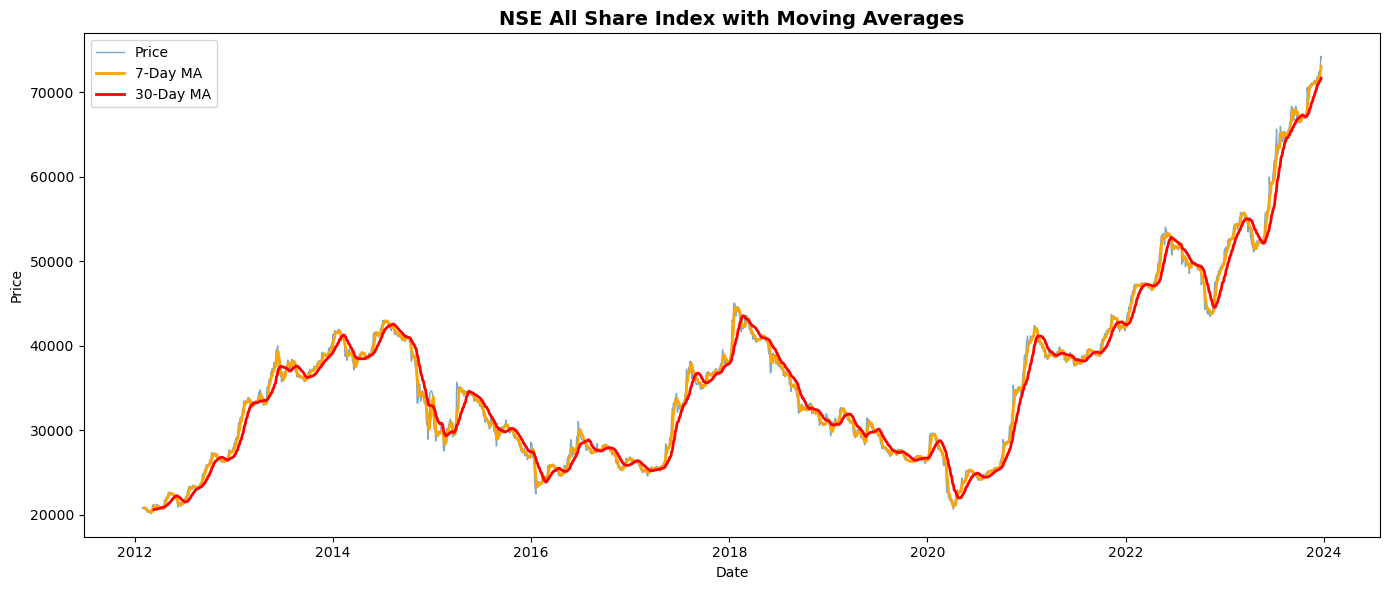

In [27]:
##  Price with Moving Averages

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=1, label='Price', alpha=0.7)
plt.plot(df['Date'], df['MA7'], color='orange', linewidth=2, label='7-Day MA')
plt.plot(df['Date'], df['MA30'], color='red', linewidth=2, label='30-Day MA')
plt.title('NSE All Share Index with Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

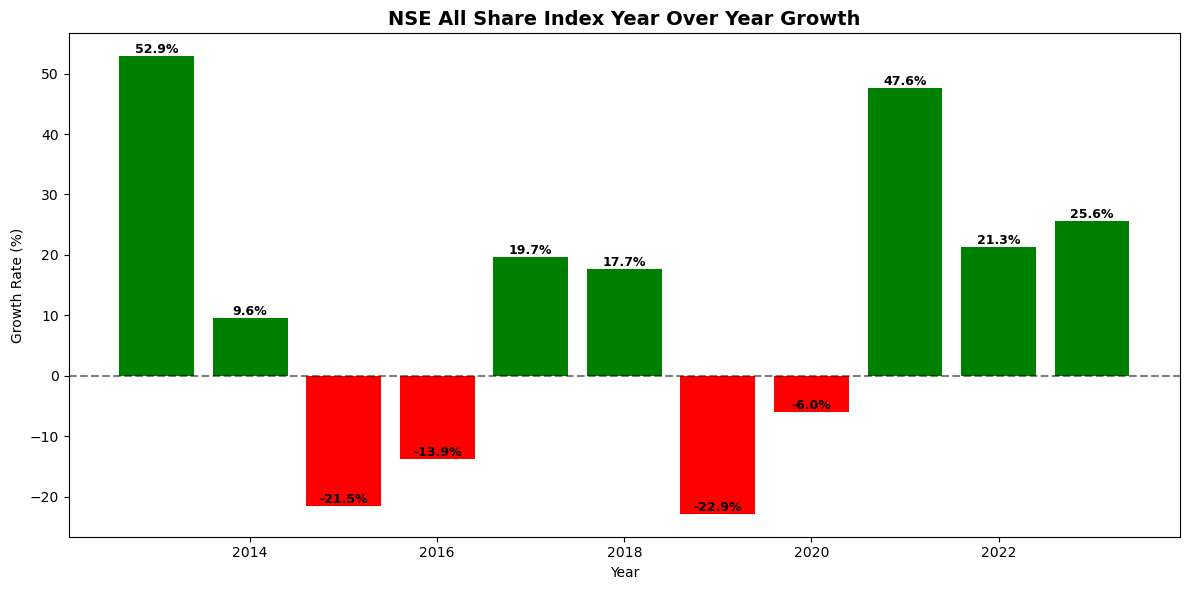

In [28]:
##  Year Over Year Growth

yearly_growth = yearly['YoY Growth'].dropna()
colors = ['green' if x > 0 else 'red' for x in yearly_growth]
plt.figure(figsize=(12,6))
plt.bar(yearly_growth.index, yearly_growth, color=colors)
plt.title('NSE All Share Index Year Over Year Growth', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(yearly_growth):
    plt.text(yearly_growth.index[i], v+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

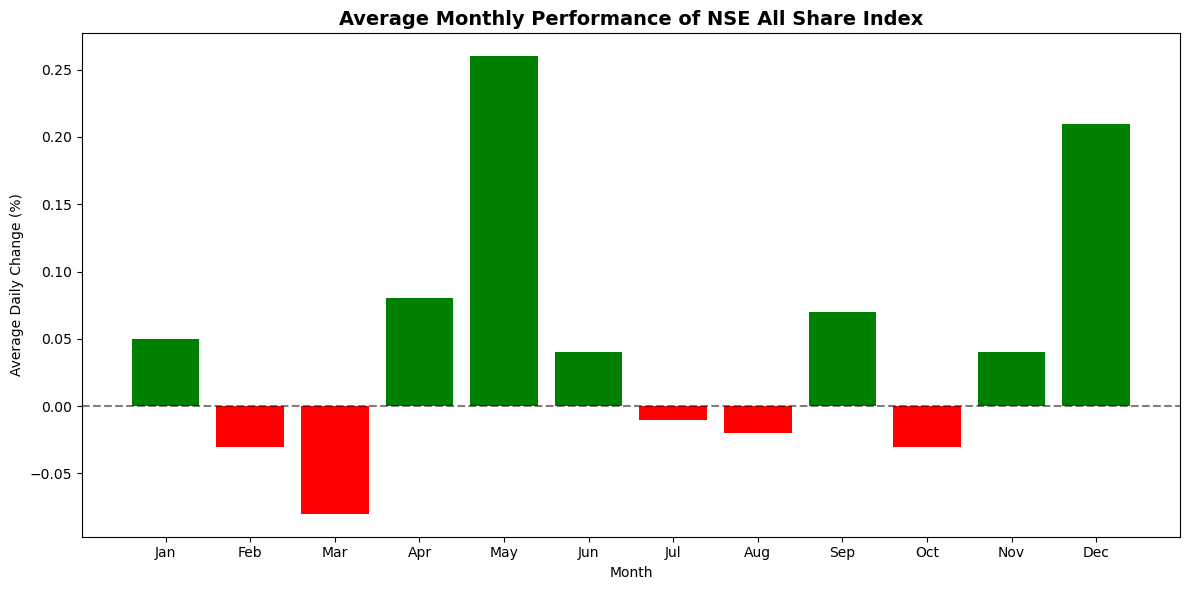

In [29]:
##   Best and Worst Months

colors = ['green' if x > 0 else 'red' for x in monthly_perf]
plt.figure(figsize=(12,6))
plt.bar(monthly_perf.index, monthly_perf, color=colors)
plt.title('Average Monthly Performance of NSE All Share Index', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daily Change (%)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

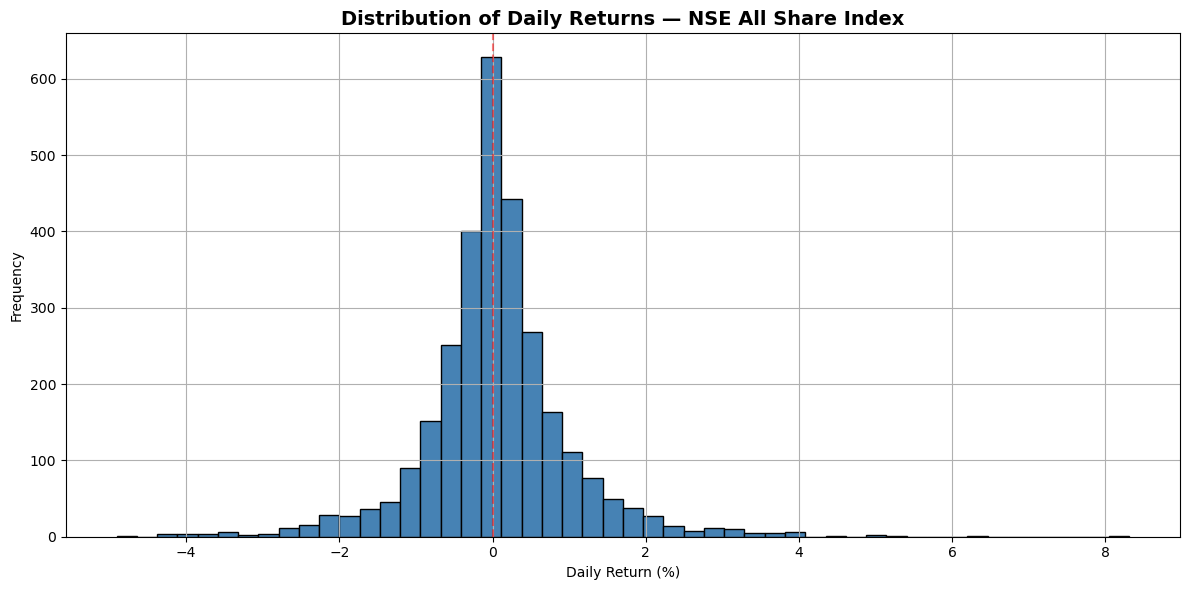

In [30]:
##  Daily Returns Distribution

plt.figure(figsize=(12,6))
df['Daily_Return'].dropna().hist(bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Distribution of Daily Returns — NSE All Share Index', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

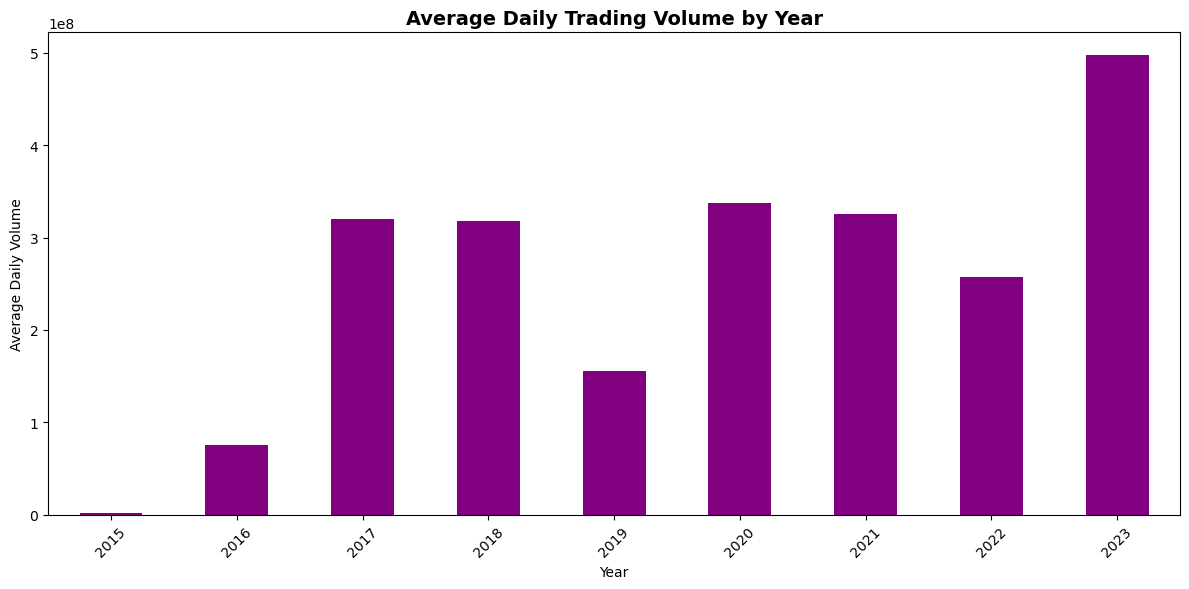

In [31]:
##   Trading Volume by Year

plt.figure(figsize=(12,6))
yearly_volume[yearly_volume > 0].plot(kind='bar', color='purple')
plt.title('Average Daily Trading Volume by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Daily Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

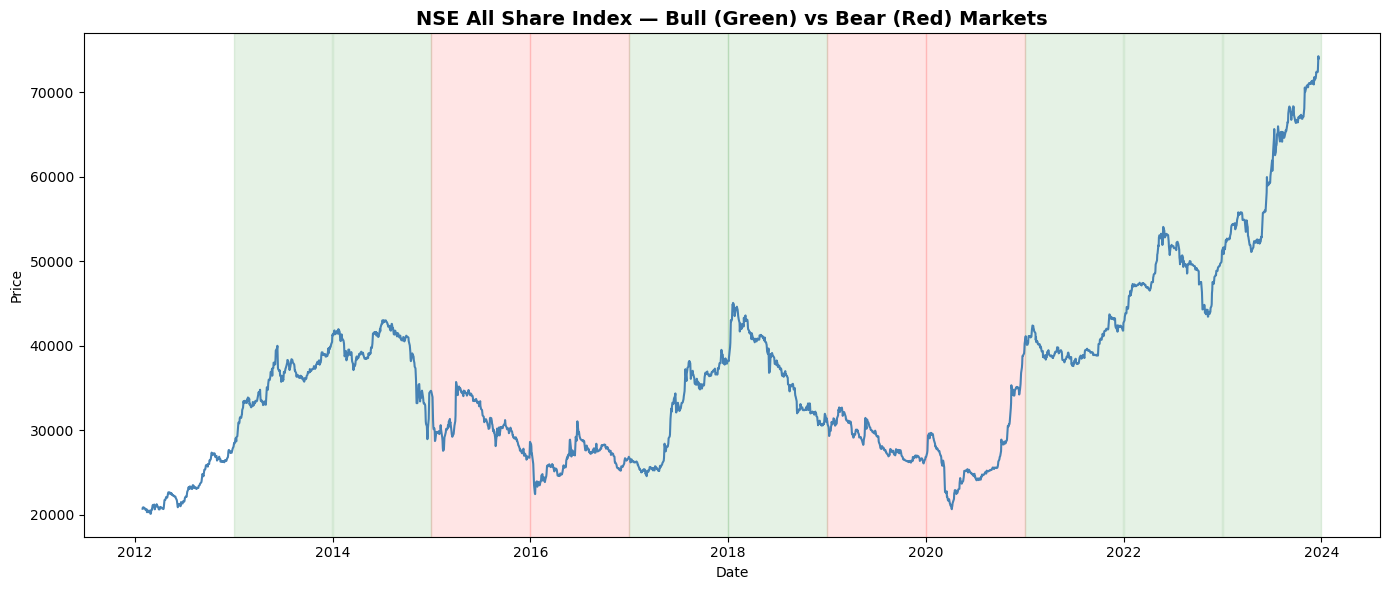

In [32]:
##  Bull and Bear Markets

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=1.5)
bull_years = [2013, 2014, 2017, 2018, 2021, 2022, 2023]
bear_years = [2015, 2016, 2019, 2020]
for year in bull_years:
    plt.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'), 
                alpha=0.1, color='green')
for year in bear_years:
    plt.axvspan(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'), 
                alpha=0.1, color='red')
plt.title('NSE All Share Index — Bull (Green) vs Bear (Red) Markets', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [33]:
df.to_csv('nse_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
